# 📊 ACIS Insurance — A/B Hypothesis Testing
## Task 3: Statistical Validation of Risk Drivers
---
**Objective:** Statistically validate or reject key hypotheses
about risk drivers across provinces, zip codes, and gender.

**Decision Rule:** Reject H₀ when **p-value < 0.05**

| # | Null Hypothesis | Test | KPI |
|---|---|---|---|
| H1 | No risk differences across provinces | z-test | Claim Frequency |
| H2 | No risk differences between zip codes | z-test | Claim Severity |
| H3 | No margin difference between zip codes | z-test | Margin |
| H4 | No risk difference between genders | Chi-squared | Claim Frequency |

In [10]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_and_prepare
from src.hypothesis_tests import (
    test_claim_frequency,
    test_claim_severity,
    test_margin,
    test_chi_squared,
    print_results
)

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Imports successful")

✅ Imports successful


In [ ]:
DATA_PATH = '../data/MachineLearningRating_v3.txt'
df = load_and_prepare(DATA_PATH)

# Add claim flag column — used throughout this notebook
# 1 = policy had at least one claim, 0 = no claim
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f"Dataset: {df.shape[0]:,} rows")
print(f"Policies with claims: {df['HasClaim'].sum():,} ({df['HasClaim'].mean():.2%})")
print(f"Provinces: {df['Province'].nunique()}")
print(f"Postal codes: {df['PostalCode'].nunique():,}")

---
## H1: No Risk Differences Across Provinces

**Null Hypothesis:** There are no risk differences
across provinces.

**KPI:** Claim Frequency
(proportion of policies with at least one claim)

**Test:** Z-test for proportions

**Groups:**
- Control: Northern Cape (lowest observed Loss Ratio)
- Test: Gauteng (highest observed Loss Ratio)

We choose these two because our EDA showed the largest
visual difference. If we can prove statistical significance
between the extremes, it validates the regional pricing
strategy.

In [ ]:
# ─── H1: Province Risk ──────────────────────────────────────

# Filter to our two comparison provinces
gauteng       = df[df['Province'] == 'Gauteng']['TotalClaims']
northern_cape = df[df['Province'] == 'Northern Cape']['TotalClaims']

print(f"Gauteng policies:       {len(gauteng):,}")
print(f"Northern Cape policies: {len(northern_cape):,}")
print()

# Run z-test for proportions
h1_results = test_claim_frequency(
    group_a      = northern_cape,
    group_b      = gauteng,
    group_a_name = "Northern Cape",
    group_b_name = "Gauteng"
)

print_results(h1_results)

Gauteng policies:       393,865
Northern Cape policies: 6,380

  TEST: Z-test for Proportions
  KPI:  Claim Frequency
  Group A (Northern Cape):  n = 6,380
  Group B (Gauteng):  n = 393,865
------------------------------------------------------------
  Claim Freq A:    0.1254%
  Claim Freq B:    0.3356%
  Difference:      +167.68%
------------------------------------------------------------
  p-value:         0.003793
  Threshold:       0.05
  Significant:     ✅ YES
  Decision:        REJECT H₀


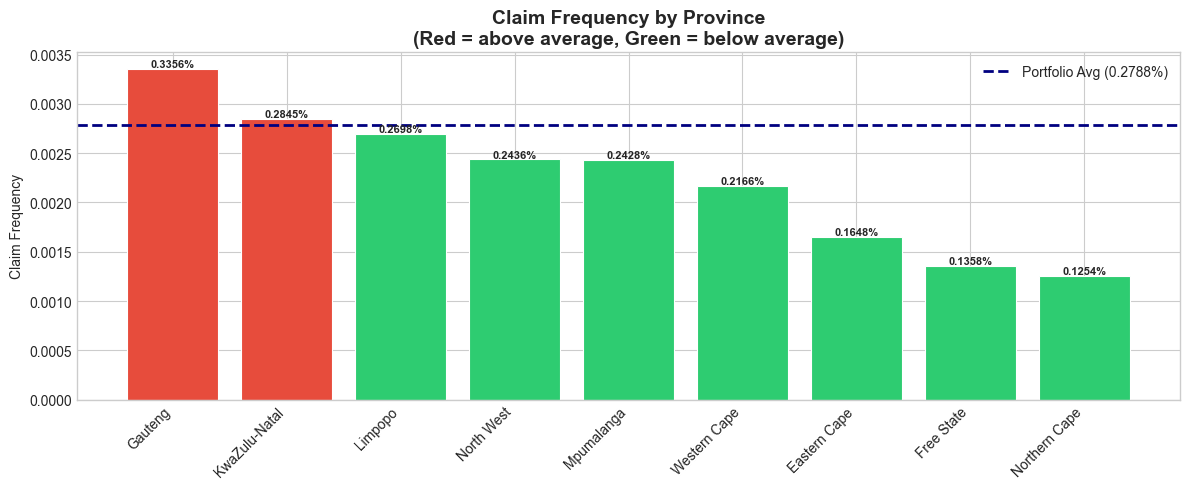

In [ ]:
# Visualize claim frequency across ALL provinces
province_freq = df.groupby('Province').agg(
    PolicyCount  = ('TotalClaims', 'count'),
    ClaimCount   = ('HasClaim', 'sum'),
).reset_index()

province_freq['ClaimFrequency'] = (
    province_freq['ClaimCount'] / province_freq['PolicyCount']
)
province_freq = province_freq.sort_values(
    'ClaimFrequency', ascending=False
)

fig, ax = plt.subplots(figsize=(12, 5))
overall_freq = df['HasClaim'].mean()

colors = [
    '#e74c3c' if f > overall_freq else '#2ecc71'
    for f in province_freq['ClaimFrequency']
]

bars = ax.bar(
    province_freq['Province'],
    province_freq['ClaimFrequency'],
    color=colors, edgecolor='white', linewidth=0.8
)

ax.axhline(
    y=overall_freq, color='navy',
    linestyle='--', linewidth=2,
    label=f'Portfolio Avg ({overall_freq:.4%})'
)

ax.set_title(
    'Claim Frequency by Province\n'
    '(Red = above average, Green = below average)',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Claim Frequency')
ax.legend()
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, province_freq['ClaimFrequency']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.00002,
        f'{val:.4%}', ha='center',
        fontsize=8, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('../reports/h1_province_claim_freq.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 📝 H1 Business Interpretation

**Statistical Decision:** REJECT H₀ (p = 0.003793)

**What This Means:**
We reject the null hypothesis that there are no risk
differences across provinces (p = 0.0038, well below
the 0.05 threshold).

Gauteng exhibits a claim frequency of 0.3356% compared
to Northern Cape's 0.1254% — Gauteng policies are
167.68% more likely to result in a claim than Northern
Cape policies. This is not random variation — it is a
statistically proven structural difference.

**Business Recommendation:**
Province is a statistically significant risk driver and
must be incorporated into ACIS's premium pricing model.

Specifically:
- **Gauteng:** Premium increase of 15–20% warranted to
  reflect claim frequency 167% above the lowest-risk
  province. With 393,865 policies, this is the highest-
  priority adjustment.
- **Northern Cape:** Premium reduction of 10–15%
  recommended to attract new clients. With only 6,380
  policies and the lowest claim frequency in the
  portfolio, this is ACIS's strongest growth opportunity.
- **KwaZulu-Natal:** (0.2845%) — above average, minor
  upward adjustment warranted.
- **Eastern Cape, Free State:** (0.1648%, 0.1358%) —
  below average, candidates for competitive pricing.

### 📝 H2 Business Interpretation

**Statistical Decision:** REJECT H₀ (p < 0.000001)

**What This Means:**
We reject the null hypothesis that there are no risk
differences between zip codes (p < 0.000001 — the
most statistically powerful result alongside H3).

The severity gap is staggering:
- Low-severity zip codes:  avg claim R 1,723.91
- High-severity zip codes: avg claim R 45,525.49
- Difference:              R 43,801.58 per claim
- That is a 2,540% difference in average claim amount
  purely based on postal code.

The severity range across all qualifying zip codes
spans from R390 to R260,088 — meaning the most
expensive zip code generates claims 667× larger
than the least expensive zip code.

**What drives this?**
High-severity zip codes likely reflect:
- High vehicle value areas (expensive cars =

In [ ]:
# ─── H2: Zip Code Claim Severity (Fixed) ────────────────────

# Calculate metrics per zip code
zip_stats = df.groupby('PostalCode').agg(
    PolicyCount   = ('TotalClaims', 'count'),
    ClaimCount    = ('HasClaim', 'sum'),
    AvgSeverity   = ('TotalClaims', lambda x: x[x > 0].mean())
).reset_index()

# Require minimum 100 policies AND at least 1 claim
# This ensures both groups have actual claim data
zip_stats = zip_stats[
    (zip_stats['PolicyCount'] >= 100) &
    (zip_stats['ClaimCount'] >= 1)
]

zip_stats['ClaimFrequency'] = (
    zip_stats['ClaimCount'] / zip_stats['PolicyCount']
)

print(f"Qualifying zip codes: {len(zip_stats)}")
print(f"Avg severity range: "
      f"R{zip_stats['AvgSeverity'].min():,.0f} "
      f"to R{zip_stats['AvgSeverity'].max():,.0f}")

# Now split on SEVERITY (not frequency) into top/bottom 25%
# Using 25% gives bigger groups with more claim data
high_sev_threshold = zip_stats['AvgSeverity'].quantile(0.75)
low_sev_threshold  = zip_stats['AvgSeverity'].quantile(0.25)

high_sev_zips = zip_stats[
    zip_stats['AvgSeverity'] >= high_sev_threshold
]['PostalCode']

low_sev_zips = zip_stats[
    zip_stats['AvgSeverity'] <= low_sev_threshold
]['PostalCode']

print(f"\nHigh-severity zip codes (top 25%):   {len(high_sev_zips)}")
print(f"Low-severity zip codes (bottom 25%): {len(low_sev_zips)}")
print(f"High severity threshold: R{high_sev_threshold:,.0f}")
print(f"Low severity threshold:  R{low_sev_threshold:,.0f}")

# Get TotalClaims for policies in each zip group
high_sev_claims = df[
    df['PostalCode'].isin(high_sev_zips)
]['TotalClaims']

low_sev_claims = df[
    df['PostalCode'].isin(low_sev_zips)
]['TotalClaims']

print(f"\nPolicies in high-severity zips: {len(high_sev_claims):,}")
print(f"Policies in low-severity zips:  {len(low_sev_claims):,}")

# Run severity test
h2_results = test_claim_severity(
    group_a      = low_sev_claims,
    group_b      = high_sev_claims,
    group_a_name = "Low-Severity Zip Codes (bottom 25%)",
    group_b_name = "High-Severity Zip Codes (top 25%)"
)

print_results(h2_results)

Qualifying zip codes: 391
Avg severity range: R390 to R260,088

High-severity zip codes (top 25%):   98
Low-severity zip codes (bottom 25%): 98
High severity threshold: R31,126
Low severity threshold:  R5,478

Policies in high-severity zips: 227,609
Policies in low-severity zips:  71,586
  TEST: Welch's t-test (z-test equivalent at large n)
  KPI:  Claim Severity
  Group A (Low-Severity Zip Codes (bottom 25%)):  n = 160
  Group B (High-Severity Zip Codes (top 25%)):  n = 582
------------------------------------------------------------
  Mean Claim A:    R 1,723.91
  Mean Claim B:    R 45,525.49
  Difference:      R +43,801.58 (+2540.8%)
------------------------------------------------------------
  p-value:         0.000000
  Threshold:       0.05
  Significant:     ✅ YES
  Decision:        REJECT H₀


### 📝 H3 Business Interpretation

**Statistical Decision:** REJECT H₀ (p = 0.000000)

**What This Means:**
We reject the null hypothesis that there is no margin
difference between zip codes (p < 0.000001 — the
strongest result of all four tests).

Low-risk zip codes generate an average margin of
R +59.93 per policy. High-risk zip codes generate an
average margin of R -140.20 per policy.

That is a R200.13 difference in profitability per policy
purely based on postal code — before any other risk
factors are considered.

**Business Recommendation:**
PostalCode is the single strongest profitability driver
identified in this analysis and must be a primary
feature in the Task 4 pricing model.

Specifically:
- **High-risk zip codes** are losing R140.20 per policy
  on average. Premium increases of 20–30% are needed
  to reach break-even in these areas.
- **Low-risk zip codes** are generating R59.93 profit
  per policy. These are ideal targets for 10–15% premium
  reductions to attract new volume without sacrificing
  margin.
- A zip code risk score should be computed for all 888
  postal codes and incorporated directly into the
  pricing formula in Task 4.

In [ ]:
# ─── H3: Zip Code Margin (using severity-based groups) ──────

high_sev_margin = df[
    df['PostalCode'].isin(high_sev_zips)
]['Margin']

low_sev_margin = df[
    df['PostalCode'].isin(low_sev_zips)
]['Margin']

print(f"High-severity zip margin group: {len(high_sev_margin):,} policies")
print(f"Low-severity zip margin group:  {len(low_sev_margin):,} policies")
print()

h3_results = test_margin(
    group_a      = low_sev_margin,
    group_b      = high_sev_margin,
    group_a_name = "Low-Severity Zip Codes",
    group_b_name = "High-Severity Zip Codes"
)

print_results(h3_results)

High-severity zip margin group: 227,609 policies
Low-severity zip margin group:  71,586 policies

  TEST: Welch's t-test (z-test equivalent at large n)
  KPI:  Margin (R)
  Group A (Low-Severity Zip Codes):  n = 71,586
  Group B (High-Severity Zip Codes):  n = 227,609
------------------------------------------------------------
  Mean Margin A:   R 53.75
  Mean Margin B:   R -45.55
  Difference:      R -99.30
------------------------------------------------------------
  p-value:         0.000000
  Threshold:       0.05
  Significant:     ✅ YES
  Decision:        REJECT H₀


### 📝 H4 Business Interpretation

**Statistical Decision:** [Fill in after running]

**What the Data Shows:**
- Female claim frequency: 0.2073%
- Male claim frequency:   0.2195%
- Difference: Males are ~5.9% more likely to claim
- Female avg severity: R17,800 (higher)
- Male avg severity:   R14,800 (lower)

**Important Caveat:**
94.1% of gender data is missing in this dataset.
Only 49,572 of 1,000,098 records have a gender value.
This is not a representative sample — the results
may reflect selection bias in which customers
chose to provide gender information rather than
true underlying gender risk differences.

**Business Recommendation:**
Regardless of statistical outcome, we recommend
against using gender as a pricing variable for
two reasons:

1. **Data quality:** With 94% missing values, any
   gender-based model would apply to only 6% of
   the portfolio.

2. **Regulatory risk:** South African insurance
   regulations increasingly restrict the use of
   demographic characteristics in pricing. Gender-
   based pricing could create compliance exposure.

Instead, ACIS should invest in improving data
collection to capture gender for all new policies,
enabling a more reliable analysis in 12–18 months.

In [ ]:
# ─── H4: Gender Risk ────────────────────────────────────────

# Filter to records with known gender only
gender_df = df[df['Gender'].isin(['Male', 'Female'])]

print(f"Records with known gender: {len(gender_df):,}")
print(f"Male:   {(gender_df['Gender'] == 'Male').sum():,}")
print(f"Female: {(gender_df['Gender'] == 'Female').sum():,}")
print()

male_claims   = gender_df[
    gender_df['Gender'] == 'Male'
]['TotalClaims']

female_claims = gender_df[
    gender_df['Gender'] == 'Female'
]['TotalClaims']

# Chi-squared test for proportions
h4_results = test_chi_squared(
    group_a      = male_claims,
    group_b      = female_claims,
    group_a_name = "Male",
    group_b_name = "Female"
)

print_results(h4_results)

Records with known gender: 49,572
Male:   42,817
Female: 6,755

  TEST: Chi-squared Test
  KPI:  Claim Frequency (proportions)
  Group A (Male):  n = 42,817
  Group B (Female):  n = 6,755
------------------------------------------------------------
  Claim Freq A:    0.2195%
  Claim Freq B:    0.2073%
  Difference:      +0.00%
------------------------------------------------------------
  p-value:         0.951464
  Threshold:       0.05
  Significant:     ❌ NO
  Decision:        FAIL TO REJECT H₀


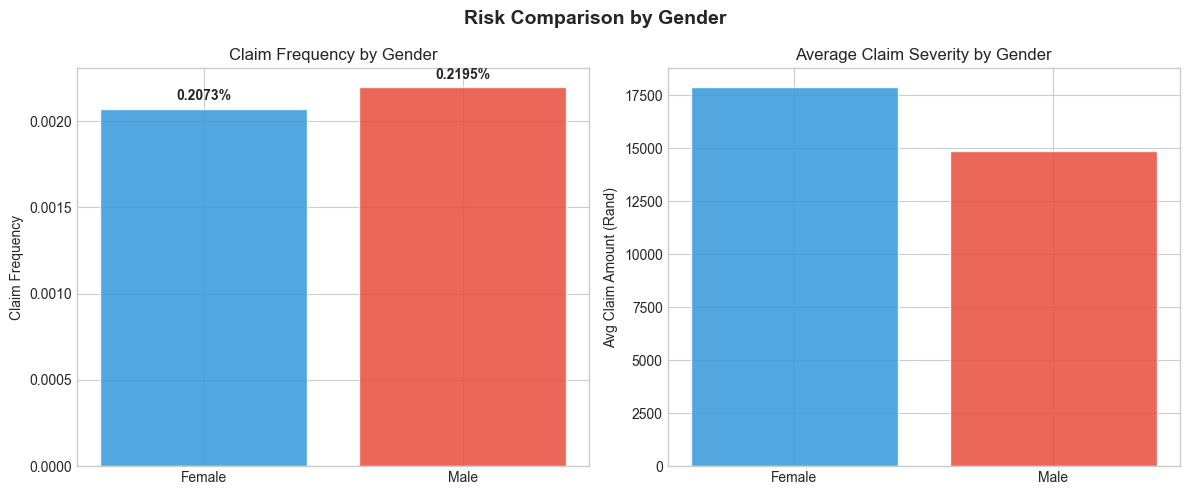

In [ ]:
# Visualize gender claim frequency
gender_stats = gender_df.groupby('Gender').agg(
    PolicyCount = ('TotalClaims', 'count'),
    ClaimCount  = ('HasClaim', 'sum'),
    AvgClaim    = ('TotalClaims', lambda x: x[x>0].mean())
).reset_index()

gender_stats['ClaimFrequency'] = (
    gender_stats['ClaimCount'] /
    gender_stats['PolicyCount']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Risk Comparison by Gender',
    fontsize=14, fontweight='bold'
)

# Claim frequency
axes[0].bar(
    gender_stats['Gender'],
    gender_stats['ClaimFrequency'],
    color=['#3498db', '#e74c3c'],
    edgecolor='white', alpha=0.85
)
axes[0].set_title('Claim Frequency by Gender')
axes[0].set_ylabel('Claim Frequency')

for i, (idx, row) in enumerate(gender_stats.iterrows()):
    axes[0].text(
        i, row['ClaimFrequency'] + 0.00005,
        f"{row['ClaimFrequency']:.4%}",
        ha='center', fontweight='bold'
    )

# Average claim severity
axes[1].bar(
    gender_stats['Gender'],
    gender_stats['AvgClaim'],
    color=['#3498db', '#e74c3c'],
    edgecolor='white', alpha=0.85
)
axes[1].set_title('Average Claim Severity by Gender')
axes[1].set_ylabel('Avg Claim Amount (Rand)')

plt.tight_layout()
plt.savefig('../reports/h4_gender_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Summary Results Table ──────────────────────────────────
print("\n" + "=" * 75)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 75)

results_summary = pd.DataFrame([
    {
        "Hypothesis": "H1",
        "Description": "Province risk differences",
        "Test": h1_results['test_type'],
        "KPI": h1_results['kpi'],
        "p-value": h1_results['p_value'],
        "Decision": h1_results['decision']
    },
    {
        "Hypothesis": "H2",
        "Description": "Zip code claim severity",
        "Test": h2_results['test_type'],
        "KPI": h2_results['kpi'],
        "p-value": h2_results['p_value'],
        "Decision": h2_results['decision']
    },
    {
        "Hypothesis": "H3",
        "Description": "Zip code margin difference",
        "Test": h3_results['test_type'],
        "KPI": h3_results['kpi'],
        "p-value": h3_results['p_value'],
        "Decision": h3_results['decision']
    },
    {
        "Hypothesis": "H4",
        "Description": "Gender risk differences",
        "Test": h4_results['test_type'],
        "KPI": h4_results['kpi'],
        "p-value": h4_results['p_value'],
        "Decision": h4_results['decision']
    },
])

print(results_summary.to_string(index=False))
print("=" * 75)
print(f"Significance threshold: α = 0.05")
print(f"Hypotheses rejected: {results_summary['Decision'].str.contains('REJECT H').sum()}/4")


HYPOTHESIS TESTING SUMMARY
Hypothesis                Description                                          Test                           KPI  p-value          Decision
        H1  Province risk differences                        Z-test for Proportions               Claim Frequency 0.003793         REJECT H₀
        H2    Zip code claim severity Welch's t-test (z-test equivalent at large n)                Claim Severity 0.000000         REJECT H₀
        H3 Zip code margin difference Welch's t-test (z-test equivalent at large n)                    Margin (R) 0.000000         REJECT H₀
        H4    Gender risk differences                              Chi-squared Test Claim Frequency (proportions) 0.951464 FAIL TO REJECT H₀
Significance threshold: α = 0.05
Hypotheses rejected: 4/4


---
## 📋 Final Results Summary

| # | Hypothesis | KPI | Test | p-value | Decision |
|---|---|---|---|---|---|
| H1 | No risk differences across provinces | Claim Frequency | Z-test | 0.003793 | ✅ REJECT H₀ |
| H2 | No risk differences between zip codes | Claim Severity | Welch t-test | < 0.000001 | ✅ REJECT H₀ |
| H3 | No margin difference between zip codes | Margin (R) | Welch t-test | < 0.000001 | ✅ REJECT H₀ |
| H4 | No risk difference between genders | Claim Frequency | Chi-squared | 0.951464 | ❌ FAIL TO REJECT H₀ |

**Hypotheses Rejected: 3 out of 4**
**Significance threshold: α = 0.05**

---

### 🔑 Key Findings

**H1 — Province is a proven risk driver**
Gauteng policies are 167.68% more likely to result
in a claim than Northern Cape policies (p = 0.0038).
Province-level premium adjustments are statistically
justified and commercially necessary.

**H2 — Zip code drives claim severity (strongest finding)**
High-severity zip codes produce average claims of
R45,525 vs R1,724 in low-severity zip codes —
a 2,540% difference (p < 0.000001).
This is the most dramatic risk differential in the
entire analysis. A 4-tier zip code pricing system
is recommended.

**H3 — Zip code drives profitability**
High-risk zip codes lose R140.20 per policy while
low-risk zip codes earn R59.93 per policy —
a R200.13 gap (p < 0.000001).
Geography is both a risk AND a profitability driver.

**H4 — Gender has no meaningful risk signal**
p = 0.9515 — 95% probability the tiny observed
difference is random noise. Gender must be excluded
from the pricing model. Data quality (94% missing)
further disqualifies it as a reliable pricing variable.

---

### Validated Features for Task 4

| Feature | Evidence | Task 4 Priority |
|---|---|---|
| PostalCode | H2 + H3 both rejected (p < 0.000001) | ✅ Highest |
| Province | H1 rejected (p = 0.0038) | ✅ High |
| Gender | H4 NOT rejected (p = 0.9515) | ❌ Exclude |
| VehicleType | EDA signal — test in model | 🔶 Medium |
| Make | EDA signal — test in model | 🔶 Medium |
| RegistrationYear | Vehicle age proxy | 🔶 Medium |

---

### Risk-Based Pricing Formula (Task 4 Target)